# Grover's Algorithm: Amplitude Damping Simulation

PennyLane density-matrix simulation ($N \in \{16, 32, 64, 128, 256\}$) using `default.mixed`.

$$\gamma = 1 - \exp\!\left(-\frac{t_\mathrm{gate}}{T_1 \times 1000}\right)$$

`qml.AmplitudeDamping(gamma, wires=i)` is applied to every qubit after the initial Hadamard layer and after each oracle and diffuser sub-layer.


In [13]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pennylane as qml

sys.path.insert(0, os.path.abspath('../src'))

from noise.amplitude_damping import gamma_from_specs
from grover.grover import optimal_iterations

FIGURES_DIR = '../results/figures'
RESULTS_DIR = '../data/results'
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

## Hardware Parameters

In [14]:
hw = pd.read_csv('../data/hardware_specs/hardware_specs.csv')
hw['ratio'] = hw['T1_us'] * 1000 / hw['t_gate_ns']
hw['gamma'] = hw.apply(lambda r: gamma_from_specs(r['T1_us'], r['t_gate_ns']), axis=1)
display(hw[['platform', 'T1_us', 't_gate_ns', 'ratio', 'gamma']])

,platform,T1_us,t_gate_ns,ratio,gamma
0,IBM Quantum (Eagle),100,50,2000.000000,0.000500
1,Google Quantum AI (Sycamore),15,12,1250.000000,0.000800
2,Intel Tunnel Falls (spin),1000,1000,1000.000000,0.001000
3,IonQ Aria (trapped ion),10000000,135000,74074.074074,0.000013


## Noisy Grover Circuit (`default.mixed`)

In [15]:
def make_noisy_circuit(n_qubits, gamma):
    dev = qml.device('default.mixed', wires=n_qubits)

    @qml.qnode(dev)
    def circuit(k):
        # Initial Hadamard layer + damping
        for w in range(n_qubits):
            qml.Hadamard(wires=w)
        for w in range(n_qubits):
            qml.AmplitudeDamping(gamma, wires=w)

        # k Grover iterations: oracle -> damp -> diffuser -> damp
        for _ in range(k):
            qml.FlipSign(0, wires=range(n_qubits))
            for w in range(n_qubits):
                qml.AmplitudeDamping(gamma, wires=w)
            qml.GroverOperator(wires=range(n_qubits))
            for w in range(n_qubits):
                qml.AmplitudeDamping(gamma, wires=w)

        return qml.probs(wires=range(n_qubits))

    return circuit

## Sweep

In [16]:
N_values = [16, 32, 64, 128]
platforms = hw['platform'].tolist()
sweep = {}  # sweep[platform][N] = {'k_opt': int, 'ks': list, 'probs': list}

for _, row in hw.iterrows():
    platform = row['platform']
    gamma = row['gamma']
    sweep[platform] = {}
    for N in N_values:
        n_qubits = int(np.log2(N))
        k_opt = optimal_iterations(N)
        k_max = k_opt + 3
        circuit = make_noisy_circuit(n_qubits, gamma)

        ks, probs = [], []
        for k in range(k_max + 1):
            p = float(circuit(k)[0])  # all-zeros state is index 0
            ks.append(k)
            probs.append(p)

        sweep[platform][N] = {'k_opt': k_opt, 'ks': ks, 'probs': probs}
        print(f'  {platform}  N={N}  k_opt={k_opt}  P(k_opt)={probs[k_opt]:.4f}')
    print(f'{platform}: done')


  IBM Quantum (Eagle)  N=16  k_opt=3  P(k_opt)=0.9589
  IBM Quantum (Eagle)  N=32  k_opt=4  P(k_opt)=0.9955
  IBM Quantum (Eagle)  N=64  k_opt=6  P(k_opt)=0.9904


KeyboardInterrupt: 

## Threshold Detection & Export

In [ ]:
records = []
for _, row in hw.iterrows():
    platform = row['platform']
    for N in N_values:
        r = sweep[platform][N]
        classical = 1.0 / N
        threshold_depth = next(
            (k for k, p in zip(r['ks'], r['probs']) if p < classical),
            float('nan'),
        )
        best_success = r['probs'][r['k_opt']]  # P(success) at k_opt
        records.append({
            'platform': platform,
            'N': N,
            'threshold_depth': threshold_depth,
            'best_success': best_success,
            'T1_us': row['T1_us'],
            't_gate_ns': row['t_gate_ns'],
            'ratio': row['ratio'],
        })

thresholds = pd.DataFrame(records)
thresholds.to_csv(f'{RESULTS_DIR}/thresholds.csv', index=False)
print(thresholds.to_string(index=False))

                    platform  N  threshold_depth  best_success    T1_us  t_gate_ns        ratio
         IBM Quantum (Eagle)  4              NaN      0.999251      100         50  2000.000000
         IBM Quantum (Eagle)  8              4.0      0.943849      100         50  2000.000000
         IBM Quantum (Eagle) 16              6.0      0.958935      100         50  2000.000000
         IBM Quantum (Eagle) 32              8.0      0.995457      100         50  2000.000000
Google Quantum AI (Sycamore)  4              NaN      0.998802       15         12  1250.000000
Google Quantum AI (Sycamore)  8              4.0      0.942973       15         12  1250.000000
Google Quantum AI (Sycamore) 16              6.0      0.957509       15         12  1250.000000
Google Quantum AI (Sycamore) 32              8.0      0.993232       15         12  1250.000000
   Intel Tunnel Falls (spin)  4              NaN      0.998503     1000       1000  1000.000000
   Intel Tunnel Falls (spin)  8         

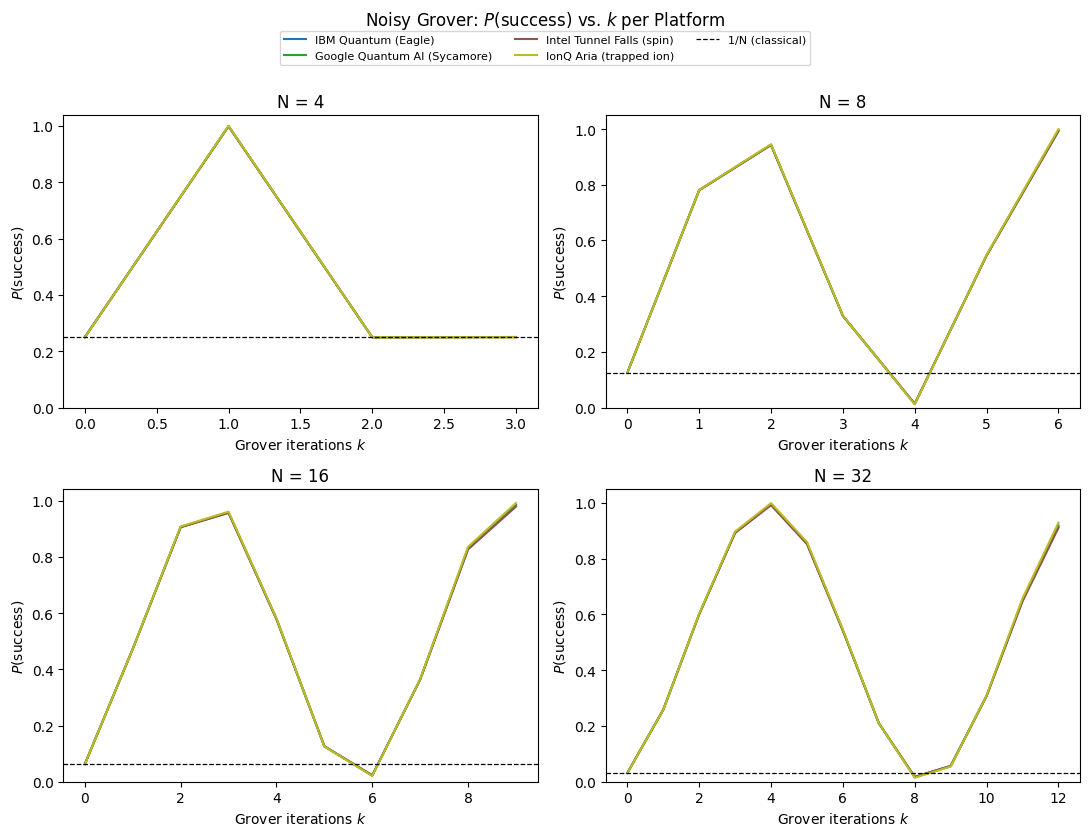

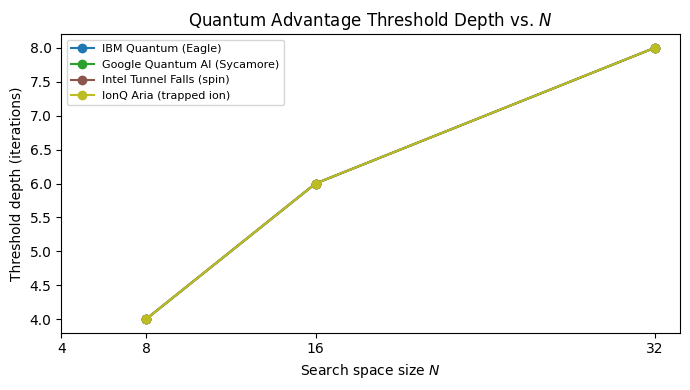

In [ ]:
colors_p = {p: c for p, c in zip(platforms, plt.cm.tab10(np.linspace(0, 0.8, len(platforms))))}

# Plot 1: 2x3 grid (5 panels, last cell hidden)
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, N in zip(axes.flat, N_values):
    classical = 1.0 / N
    for platform in platforms:
        r = sweep[platform][N]
        ax.plot(r['ks'], r['probs'], label=platform, color=colors_p[platform])
    ax.axhline(classical, color='black', linestyle='--', linewidth=0.9, label='1/N (classical)')
    ax.set_title(f'N = {N}')
    ax.set_xlabel('Grover iterations $k$')
    ax.set_ylabel('$P(\\mathrm{success})$')
    ax.set_ylim(0, None)
axes.flat[-1].set_visible(False)  # hide unused 6th panel

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower right', ncol=1, fontsize=8,
           bbox_to_anchor=(0.98, 0.08))
plt.suptitle('Noisy Grover: $P(\\mathrm{success})$ vs. $k$ per Platform')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/noisy_grover_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 2: threshold depth vs. N per platform
fig2, ax2 = plt.subplots(figsize=(8, 4))
for platform in platforms:
    sub = thresholds[thresholds['platform'] == platform].sort_values('N')
    ax2.plot(sub['N'], sub['threshold_depth'], marker='o', label=platform, color=colors_p[platform])
ax2.set_xlabel('Search space size $N$')
ax2.set_ylabel('Threshold depth (iterations)')
ax2.set_title('Quantum Advantage Threshold Depth vs. $N$')
ax2.legend(fontsize=8)
ax2.set_xscale('log', base=2)
ax2.set_xticks(N_values)
ax2.set_xticklabels([str(N) for N in N_values])
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/threshold_vs_N.png', dpi=150)
plt.show()
